# 02 · Fundamentals as of a date

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/02_fundamentals_as_of_a_date.ipynb)

**What you will learn**

- Why a backtest must use the numbers that were *public* on each date, not today's numbers.
- How `ValueinClient(as_of=...)` filters every point-in-time table to what was known at a cutoff.
- How a restated number shows up as a second vintage of the same fact.
- Why 10-Q cash flows are year-to-date, and how `derived_quarterly_value` gives the quarter.

**Plan required:** none (free sample tier, no API key).

In [1]:
%pip install -q "valuein-sdk>=7.0.0" matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. Three dates on every number

Every row of `fact` carries:

- `period_end`: the last day of the period the number describes (for example the fiscal year end).
- `accepted_at`: when the SEC accepted the filing that reported it. **This is when the number
  became public.** Point-in-time filtering uses it.
- the filing's `filing_date` (in `filing`), the calendar day of that acceptance.

A company's fiscal-year numbers exist from `period_end`, but nobody outside the company could
trade on them until `accepted_at`, often 30 to 90 days later. Using `period_end` as the "known"
date leaks the future into a backtest.

In [2]:
import warnings
from datetime import datetime, timezone

import matplotlib.pyplot as plt
import pandas as pd

from valuein_sdk import ValueinClient

client = ValueinClient()
mpwr = client.read_table("fact", tickers="MPWR")
print(len(mpwr), "fact rows for MPWR (read from its own per-company file)")


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


6999 fact rows for MPWR (read from its own per-company file)


## 2. A restatement is a new vintage, not an overwrite

Monolithic Power Systems (MPWR) reported fiscal 2024 net income in its 10-K accepted in
March 2025. A later 10-K reported a different figure for the same year, and the company filed an
8-K Item 4.02 non-reliance notice. Valuein keeps both rows. Each has its own `accession_id`
(the SEC filing number) and `accepted_at`.

In [3]:
fy2024 = mpwr[
    (mpwr["standard_concept"] == "NetIncome")
    & (mpwr["fiscal_period"] == "FY")
    & (mpwr["period_end"] == pd.Timestamp("2024-12-31"))
]
vintages = fy2024[["period_end", "numeric_value", "accession_id", "accepted_at"]]
vintages.sort_values("accepted_at").drop_duplicates(["numeric_value", "accession_id"])

,period_end,numeric_value,accession_id,accepted_at
4773,2024-12-31,1.786700e+09,0001437749-25-005903,2025-03-03 15:14:51-05:00
4789,2024-12-31,1.592058e+09,0001437749-26-006113,2026-02-27 16:33:25-05:00


## 3. Ask the same question at two dates

The SQL below never changes. Only the client's `as_of` does. `as_of` must be timezone-aware.
Every point-in-time table (`fact`, `ratio`, prices, smart-money tables) is filtered to
`accepted_at <= as_of` inside DuckDB, so even a `SELECT *` cannot see a later filing.

In [4]:
QUESTION = """
    SELECT numeric_value / 1e9 AS net_income_bn, accession_id, accepted_at
    FROM fact
    WHERE entity_id = '{cik}'
      AND standard_concept = 'NetIncome'
      AND fiscal_period = 'FY'
      AND period_end = DATE '2024-12-31'
    QUALIFY ROW_NUMBER() OVER (ORDER BY accepted_at DESC, priority DESC) = 1
"""
cik = client.resolve("MPWR")["cik"].iloc[0]
# The sample-tier notice was printed above; do not repeat it for the two clients below.
warnings.filterwarnings("ignore", message="Defaulting to SAMPLE dataset")

answers = []
for label, as_of in [
    ("known on 2025-06-30", datetime(2025, 6, 30, tzinfo=timezone.utc)),
    ("known today", None),
]:
    with ValueinClient(as_of=as_of) as past_or_present:
        row = past_or_present.run_query(QUESTION.format(cik=cik)).iloc[0]
    answers.append({"question asked": label, **row.to_dict()})
pd.DataFrame(answers)

,question asked,net_income_bn,accession_id,accepted_at
0,known on 2025-06-30,1.786700,0001437749-25-005903,2025-03-03 15:14:51-05:00
1,known today,1.592058,0001437749-26-006113,2026-02-27 16:33:25-05:00


A backtest dated mid-2025 must use the first number: that is all anyone could have known.
A database that overwrites restated values silently hands that backtest the second number.
The size of the error is exact: any P/E computed from the original earnings during those
months used a different denominator from the one a restated database would give you.

In [5]:
first, latest = answers[0]["net_income_bn"], answers[1]["net_income_bn"]
print(f"as first reported : {first:.4f} bn")
print(f"as known today    : {latest:.4f} bn")
print(f"change            : {latest / first - 1:+.1%}")

as first reported : 1.7867 bn
as known today    : 1.5921 bn
change            : -10.9%


## 4. The quarterly cash-flow trap

Income statement items in a 10-Q cover the quarter, but most companies report the cash-flow
statement **year to date**: the Q2 10-Q shows six months, Q3 shows nine. Summing or comparing
those raw values double counts. Valuein derives the single-quarter figure in
`derived_quarterly_value` (`derivation_type = 'ytd_subtraction'`).

- Quarterly analysis: use `COALESCE(derived_quarterly_value, numeric_value)`.
- Annual analysis: use `numeric_value` on `fiscal_period = 'FY'` rows. On an FY row
  `derived_quarterly_value` is the implied fourth quarter, not the year.

In [6]:
aapl_cik = client.resolve("AAPL")["cik"].iloc[0]
ocf = client.run_query(f"""
    SELECT period_end, fiscal_period, period_span_days,
           numeric_value / 1e9          AS as_reported_bn,
           derived_quarterly_value / 1e9 AS single_quarter_bn,
           derivation_type
    FROM fact
    WHERE entity_id = '{aapl_cik}'
      AND standard_concept = 'OperatingCashFlow'
      AND period_end >= DATE '2024-01-01'
    QUALIFY ROW_NUMBER() OVER (PARTITION BY period_end, period_span_days ORDER BY accepted_at DESC, priority DESC) = 1
    ORDER BY period_end
""")
ocf.round({"as_reported_bn": 2, "single_quarter_bn": 2})

,period_end,fiscal_period,period_span_days,as_reported_bn,single_quarter_bn,derivation_type
0,2024-03-30,Q2,181,62.58,22.69,ytd_subtraction
1,2024-06-29,Q3,272,91.44,28.86,ytd_subtraction
2,2024-09-28,FY,363,118.25,26.81,ytd_subtraction
3,2024-12-28,Q1,90,29.94,29.94,standalone
4,2025-03-29,Q2,181,53.89,23.95,ytd_subtraction
5,2025-06-28,Q3,272,81.75,27.87,ytd_subtraction
6,2025-09-27,FY,363,111.48,29.73,ytd_subtraction
7,2025-12-27,Q1,90,53.92,53.92,standalone
8,2026-03-28,Q2,181,82.63,28.70,ytd_subtraction
9,2026-06-27,Q3,272,117.00,34.37,ytd_subtraction


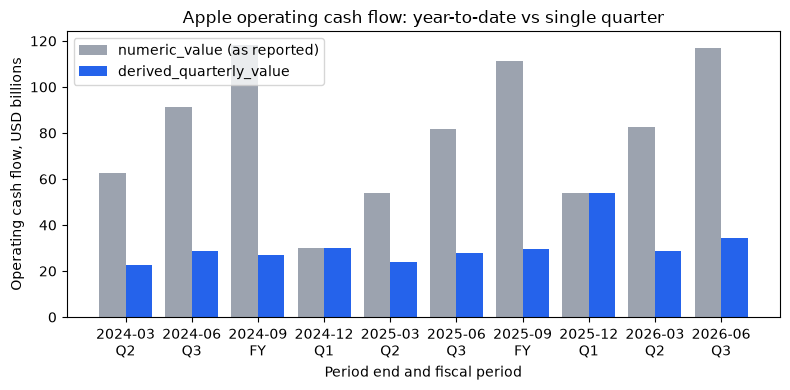

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(ocf))
ax.bar([i - 0.2 for i in x], ocf["as_reported_bn"], width=0.4, label="numeric_value (as reported)", color="#9ca3af")
ax.bar([i + 0.2 for i in x], ocf["single_quarter_bn"], width=0.4, label="derived_quarterly_value", color="#2563eb")
ax.set_xticks(list(x))
ax.set_xticklabels([f"{d:%Y-%m}\n{p}" for d, p in zip(ocf["period_end"], ocf["fiscal_period"])])
ax.set_xlabel("Period end and fiscal period")
ax.set_ylabel("Operating cash flow, USD billions")
ax.set_title("Apple operating cash flow: year-to-date vs single quarter")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Trailing twelve months from single quarters

A trailing-twelve-month (TTM) value is the sum of the last four single quarters. There is no
10-Q for the fourth quarter: it comes from the 10-K, where `derived_quarterly_value` on the `FY`
row is the implied Q4. So build the quarterly series from both forms, keep one vintage per
`period_end`, and only accept a sum whose four quarters really span one year.

In [8]:
quarters = client.run_query(f"""
    SELECT period_end, fiscal_period,
           COALESCE(derived_quarterly_value, numeric_value) / 1e9 AS quarter_bn
    FROM fact
    WHERE entity_id = '{aapl_cik}'
      AND standard_concept = 'OperatingCashFlow'
      AND fiscal_period IN ('Q1', 'Q2', 'Q3', 'FY')
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY period_end ORDER BY accepted_at DESC, period_span_days DESC, priority DESC) = 1
    ORDER BY period_end
""")
quarters["ttm_bn"] = quarters["quarter_bn"].rolling(4).sum()
# Four consecutive quarter ends sit about 273 days apart; anything else means a quarter is missing.
spans_one_year = quarters["period_end"].diff(3).dt.days.between(260, 290)
quarters.loc[~spans_one_year, "ttm_bn"] = float("nan")
quarters.tail(8).round({"quarter_bn": 2, "ttm_bn": 2})

,period_end,fiscal_period,quarter_bn,ttm_bn
14,2024-09-28,FY,26.81,118.25
15,2024-12-28,Q1,29.94,108.29
16,2025-03-29,Q2,23.95,109.56
17,2025-06-28,Q3,27.87,108.57
18,2025-09-27,FY,29.73,111.48
19,2025-12-27,Q1,53.92,135.47
20,2026-03-28,Q2,28.70,140.22
21,2026-06-27,Q3,34.37,146.72


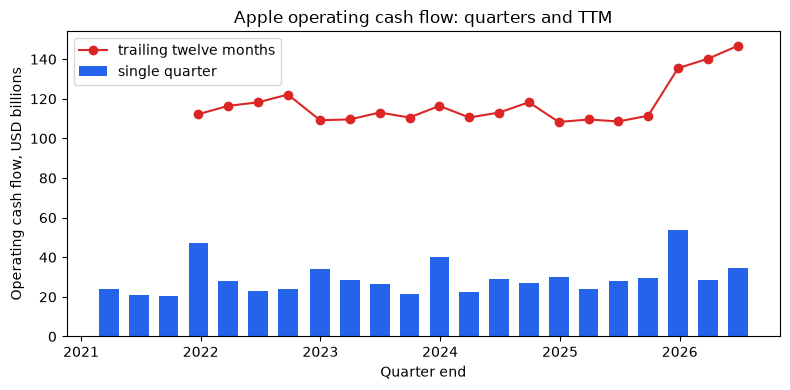

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(quarters["period_end"], quarters["quarter_bn"], width=60, color="#2563eb", label="single quarter")
ax.plot(quarters["period_end"], quarters["ttm_bn"], color="#dc2626", marker="o", label="trailing twelve months")
ax.set_xlabel("Quarter end")
ax.set_ylabel("Operating cash flow, USD billions")
ax.set_title("Apple operating cash flow: quarters and TTM")
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
client.close()

## Rules to copy into your own code

1. Gate on `accepted_at <= your_date` (set `ValueinClient(as_of=...)` and the SDK does it for
   you). Never gate on `period_end` or `report_date`.
2. Pick a vintage on purpose: latest `accepted_at` for "what is known now", earliest for
   "as first reported". Break ties with `priority DESC` (`priority = 1` is the elected tag
   when several XBRL tags in one filing map to the same concept).
3. Identify periods by `period_end` plus `fiscal_period`, not by the filing.
4. Quarterly flows: `COALESCE(derived_quarterly_value, numeric_value)`. Annual flows:
   `numeric_value` on `FY` rows.

## Next steps

- **[03 · Survivorship-free screening](03_survivorship_free_screening.ipynb)**: screen the
  S&P 500 as it was on a past date, including the companies that later left it.
- Script version: [`python/pit_backtest.py`](../python/pit_backtest.py) and
  [`python/financial_analysis.py`](../python/financial_analysis.py).